<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 150.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 102.2 MB/s eta 0:00:00


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [4]:
## Write your code here
df.describe

<bound method NDFrame.describe of        ResponseId                      MainBranch                 Age  \
0               1  I am a developer by profession  Under 18 years old   
1               2  I am a developer by profession     35-44 years old   
2               3  I am a developer by profession     45-54 years old   
3               4           I am learning to code     18-24 years old   
4               5  I am a developer by profession     18-24 years old   
...           ...                             ...                 ...   
65432       65433  I am a developer by profession     18-24 years old   
65433       65434  I am a developer by profession     25-34 years old   
65434       65435  I am a developer by profession     25-34 years old   
65435       65436  I am a developer by profession     18-24 years old   
65436       65437     I code primarily as a hobby     18-24 years old   

                Employment                            RemoteWork   Check  \
0      Employ

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [5]:
## Write your code here
# Step 3: Handling Missing Data

critical_cols = ["Employment", "JobSat", "RemoteWork"]

# Missing counts BEFORE
missing_before = df[critical_cols].isna().sum().sort_values(ascending=False)
print("Missing values (before):")
display(missing_before)

# Impute missing with most frequent (mode) for categorical columns
for col in critical_cols:
    if col in df.columns:
        mode_val = df[col].mode(dropna=True)
        if len(mode_val) > 0:
            df[col] = df[col].fillna(mode_val[0])

# Missing counts AFTER
missing_after = df[critical_cols].isna().sum().sort_values(ascending=False)
print("Missing values (after):")
display(missing_after)

Missing values (before):


JobSat        36311
RemoteWork    10631
Employment        0
dtype: int64

Missing values (after):


Employment    0
JobSat        0
RemoteWork    0
dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



Median JobSat (score) by YearsCodePro range:


,ExpRange,JobSat_score
0,0-5,NaN
1,5-10,NaN
2,10-20,NaN
3,>20,NaN
4,NaN,NaN


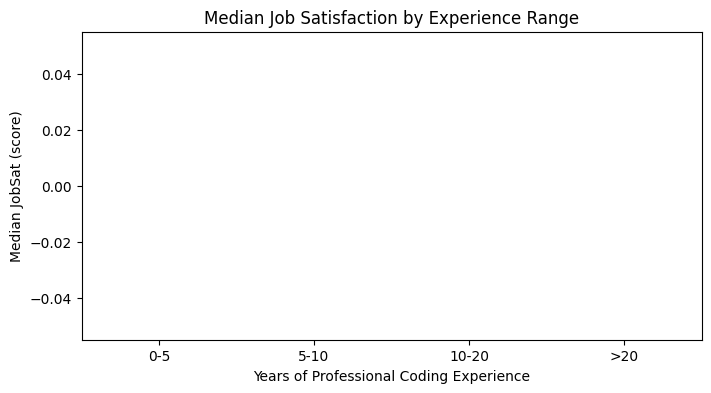

In [6]:
## Write your code here
# Step 4: Experience and Job Satisfaction (YearsCodePro vs JobSat)

# Clean YearsCodePro to numeric
years = df["YearsCodePro"].astype("string")
years = years.replace({
    "Less than 1 year": "0.5",
    "More than 50 years": "51"
})
df["YearsCodePro_num"] = pd.to_numeric(years, errors="coerce")

# Map JobSat (categorical) to an ordinal numeric scale so "median" makes sense
# If your dataset has slightly different labels, this still works for the common StackOverflow labels.
jobsat_map = {
    "Very dissatisfied": 1,
    "Slightly dissatisfied": 2,
    "Neither satisfied nor dissatisfied": 3,
    "Slightly satisfied": 4,
    "Very satisfied": 5
}
df["JobSat_score"] = df["JobSat"].map(jobsat_map)

# Create experience bins: 0-5, 5-10, 10-20, >20
bins = [-0.001, 5, 10, 20, 1000]
labels = ["0-5", "5-10", "10-20", ">20"]
df["ExpRange"] = pd.cut(df["YearsCodePro_num"], bins=bins, labels=labels)

# Median JobSat score per experience range
median_by_range = df.groupby("ExpRange", dropna=False)["JobSat_score"].median().reset_index()
print("Median JobSat (score) by YearsCodePro range:")
display(median_by_range)

# Bar plot
plt.figure(figsize=(8,4))
sns.barplot(data=median_by_range, x="ExpRange", y="JobSat_score")
plt.title("Median Job Satisfaction by Experience Range")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Median JobSat (score)")
plt.show()

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


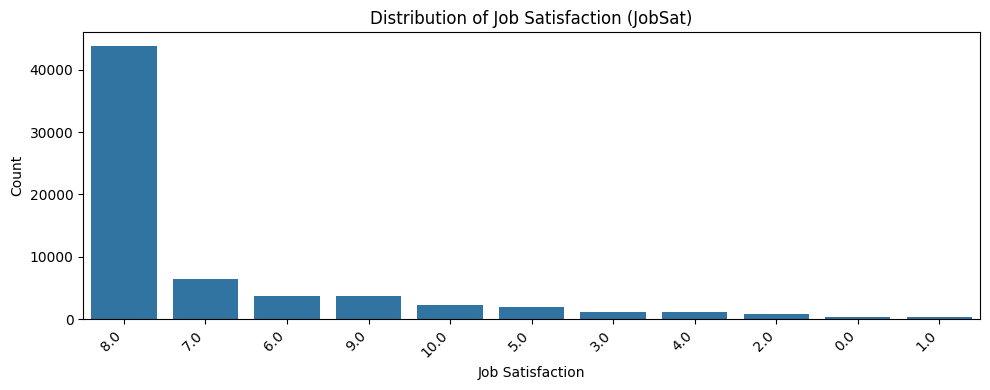

In [7]:
## Write your code here
# Step 5: Visualize Job Satisfaction distribution

plt.figure(figsize=(10,4))
sns.countplot(data=df, x="JobSat", order=df["JobSat"].value_counts(dropna=False).index)
plt.title("Distribution of Job Satisfaction (JobSat)")
plt.xlabel("Job Satisfaction")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


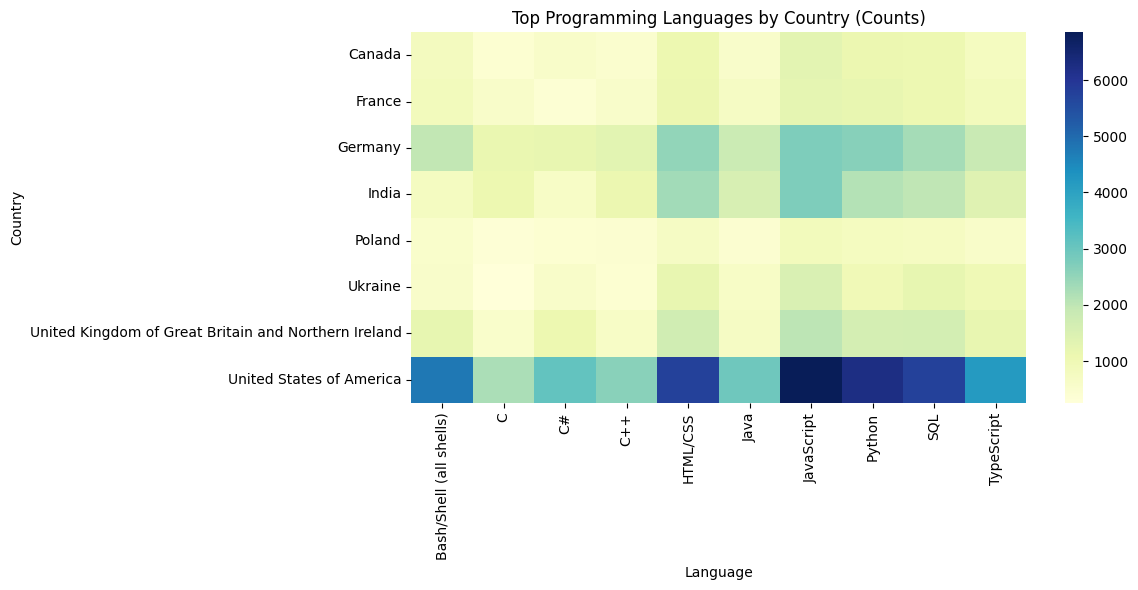

Language,Bash/Shell (all shells),C,C#,C++,HTML/CSS,Java,JavaScript,Python,SQL,TypeScript
Country,,,,,,,,,,
Canada,798.0,415.0,603.0,488.0,1097.0,571.0,1296.0,1118.0,1073.0,796.0
France,858.0,594.0,410.0,567.0,1114.0,706.0,1281.0,1186.0,1069.0,861.0
Germany,1970.0,1147.0,1185.0,1315.0,2514.0,1818.0,2732.0,2640.0,2297.0,1868.0
India,759.0,1084.0,645.0,1127.0,2322.0,1549.0,2730.0,2128.0,1986.0,1405.0
Poland,552.0,337.0,430.0,457.0,708.0,460.0,851.0,782.0,724.0,593.0
Ukraine,579.0,256.0,612.0,430.0,1198.0,664.0,1532.0,961.0,1215.0,980.0
United Kingdom of Great Britain and Northern Ireland,1231.0,563.0,1089.0,651.0,1707.0,701.0,2011.0,1634.0,1663.0,1190.0
United States of America,4776.0,2225.0,3112.0,2607.0,5754.0,2949.0,6849.0,6238.0,5766.0,4173.0


In [9]:
## Write your code here
# Pick top 8 countries by response count
top_countries = df["Country"].value_counts(dropna=True).head(8).index

# Filter and explode LanguageHaveWorkedWith (semicolon-separated)
temp = df[df["Country"].isin(top_countries)].copy()
temp["LanguageHaveWorkedWith"] = temp["LanguageHaveWorkedWith"].astype("string")

temp = temp.dropna(subset=["LanguageHaveWorkedWith"])
temp = temp.assign(Language=temp["LanguageHaveWorkedWith"].str.split(";")).explode("Language")

# Count languages per country
lang_counts = (
    temp.groupby(["Country", "Language"])
        .size()
        .reset_index(name="count")
)

# Keep top 10 languages overall (across these countries) for a cleaner chart
top_langs = lang_counts.groupby("Language")["count"].sum().sort_values(ascending=False).head(10).index
lang_counts = lang_counts[lang_counts["Language"].isin(top_langs)]

# Pivot for heatmap
pivot = lang_counts.pivot_table(index="Country", columns="Language", values="count", fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=False, cmap="YlGnBu")
plt.title("Top Programming Languages by Country (Counts)")
plt.xlabel("Language")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

display(pivot)

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


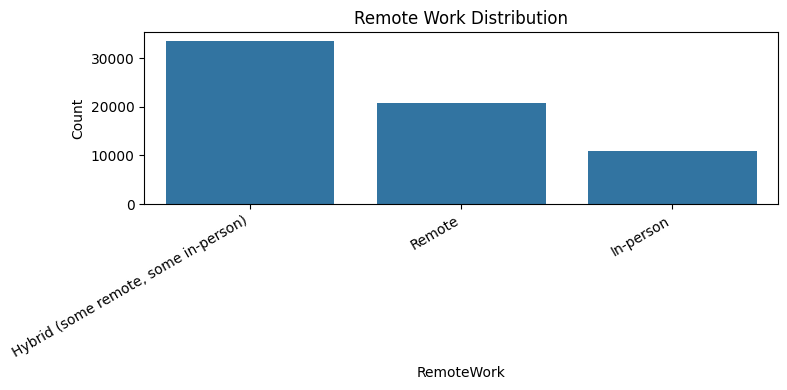

RemoteWork preference by Employment type (% within Employment):


RemoteWork,"Hybrid (some remote, some in-person)",In-person,Remote
Employment,,,
"Employed, full-time",44.30,21.91,33.79
"Employed, full-time;Employed, part-time",40.09,15.09,44.81
"Employed, full-time;Independent contractor, freelancer, or self-employed",37.39,10.29,52.32
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time",43.48,9.24,47.28
"Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired",0.00,100.00,0.00
...,...,...,...
"Student, full-time;Student, part-time;Employed, part-time",57.14,14.29,28.57
"Student, full-time;Student, part-time;Retired",100.00,0.00,0.00
"Student, part-time",100.00,0.00,0.00


/tmp/ipykernel_298/544546783.py:25: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


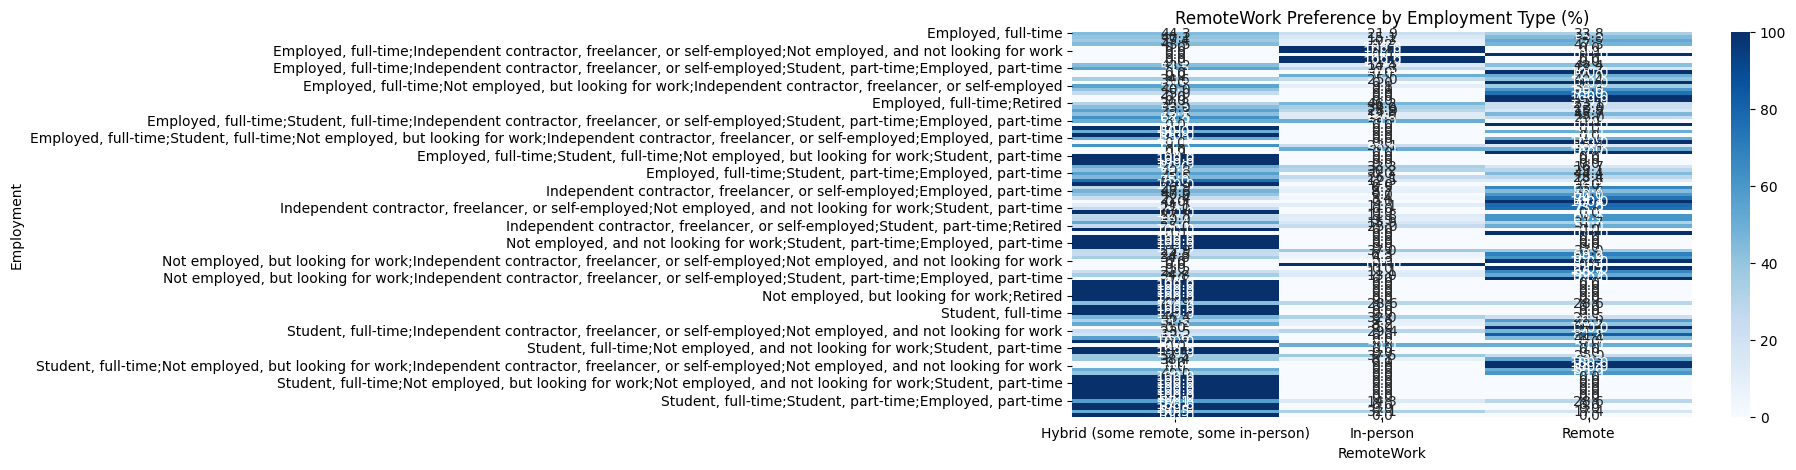

In [8]:
## Write your code here


# Count plot of RemoteWork distribution
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="RemoteWork", order=df["RemoteWork"].value_counts(dropna=False).index)
plt.title("Remote Work Distribution")
plt.xlabel("RemoteWork")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Cross-tabulate RemoteWork by Employment
ct = pd.crosstab(df["Employment"], df["RemoteWork"], dropna=False, normalize="index") * 100
print("RemoteWork preference by Employment type (% within Employment):")
display(ct.round(2))

# Heatmap for readability
plt.figure(figsize=(10,5))
sns.heatmap(ct, annot=True, fmt=".1f", cmap="Blues")
plt.title("RemoteWork Preference by Employment Type (%)")
plt.xlabel("RemoteWork")
plt.ylabel("Employment")
plt.tight_layout()
plt.show()

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


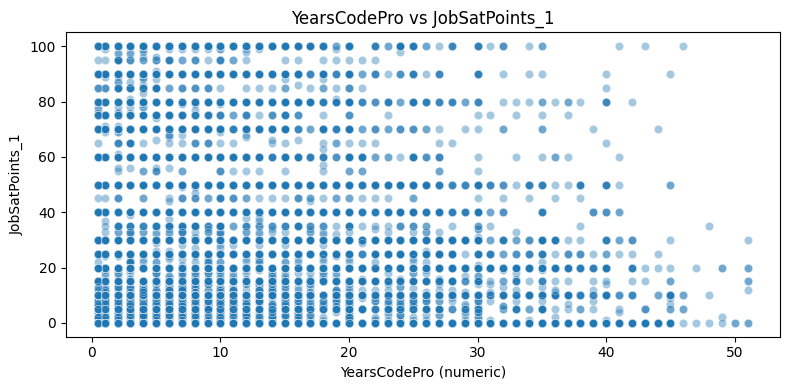

Correlation (YearsCodePro_num vs JobSatPoints_1_num): -0.028


In [10]:
## Write your code here
# Make numeric versions
df["JobSatPoints_1_num"] = pd.to_numeric(df["JobSatPoints_1"], errors="coerce")

scatter_df = df.dropna(subset=["YearsCodePro_num", "JobSatPoints_1_num"])

plt.figure(figsize=(8,4))
sns.scatterplot(data=scatter_df, x="YearsCodePro_num", y="JobSatPoints_1_num", alpha=0.4)
plt.title("YearsCodePro vs JobSatPoints_1")
plt.xlabel("YearsCodePro (numeric)")
plt.ylabel("JobSatPoints_1")
plt.tight_layout()
plt.show()

# Correlation value
corr = scatter_df["YearsCodePro_num"].corr(scatter_df["JobSatPoints_1_num"])
print("Correlation (YearsCodePro_num vs JobSatPoints_1_num):", round(corr, 3))

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


Employment distribution within each EdLevel (%):


Employment,"Employed, full-time","Employed, full-time;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Employed, part-time;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Employed, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Not employed, and not looking for work;Student, part-time","Employed, full-time;Independent contractor, freelancer, or self-employed;Retired","Employed, full-time;Independent contractor, freelancer, or self-employed;Student, part-time",...,"Student, full-time;Not employed, but looking for work;Not employed, and not looking for work","Student, full-time;Not employed, but looking for work;Not employed, and not looking for work;Student, part-time","Student, full-time;Not employed, but looking for work;Retired","Student, full-time;Not employed, but looking for work;Student, part-time","Student, full-time;Student, part-time","Student, full-time;Student, part-time;Employed, part-time","Student, full-time;Student, part-time;Retired","Student, part-time","Student, part-time;Employed, part-time","Student, part-time;Retired"
EdLevel,,,,,,,,,,,,,,,,,,,,,
"Associate degree (A.A., A.S., etc.)",59.06,0.50,5.80,0.61,0.00,0.00,0.00,0.00,0.00,0.28,...,0.00,0.0,0.00,0.00,0.11,0.00,0.00,0.67,1.34,0.00
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",67.38,0.36,5.54,0.32,0.00,0.00,0.00,0.00,0.00,0.20,...,0.00,0.0,0.00,0.01,0.05,0.00,0.00,0.42,0.74,0.00
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",70.78,0.39,6.19,0.29,0.00,0.01,0.00,0.00,0.00,0.17,...,0.00,0.0,0.01,0.00,0.01,0.01,0.00,0.17,0.55,0.01
Primary/elementary school,13.96,0.09,2.18,0.09,0.00,0.09,0.00,0.09,0.00,0.00,...,0.00,0.0,0.00,0.00,0.44,0.09,0.09,4.19,0.35,0.00
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",69.80,0.27,5.35,0.34,0.03,0.00,0.00,0.00,0.00,0.03,...,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.17,0.17,0.00
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",25.20,0.16,3.12,0.10,0.00,0.00,0.02,0.00,0.00,0.10,...,0.00,0.0,0.00,0.03,0.21,0.00,0.02,2.42,1.73,0.00
Some college/university study without earning a degree,46.78,0.20,6.43,0.18,0.00,0.00,0.00,0.00,0.01,0.51,...,0.07,0.0,0.00,0.05,0.09,0.05,0.00,0.98,1.35,0.01
Something else,40.45,0.32,4.40,0.21,0.00,0.00,0.00,0.00,0.00,0.43,...,0.00,0.0,0.00,0.11,0.54,0.00,0.00,1.82,1.50,0.11


/tmp/ipykernel_298/2086958014.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


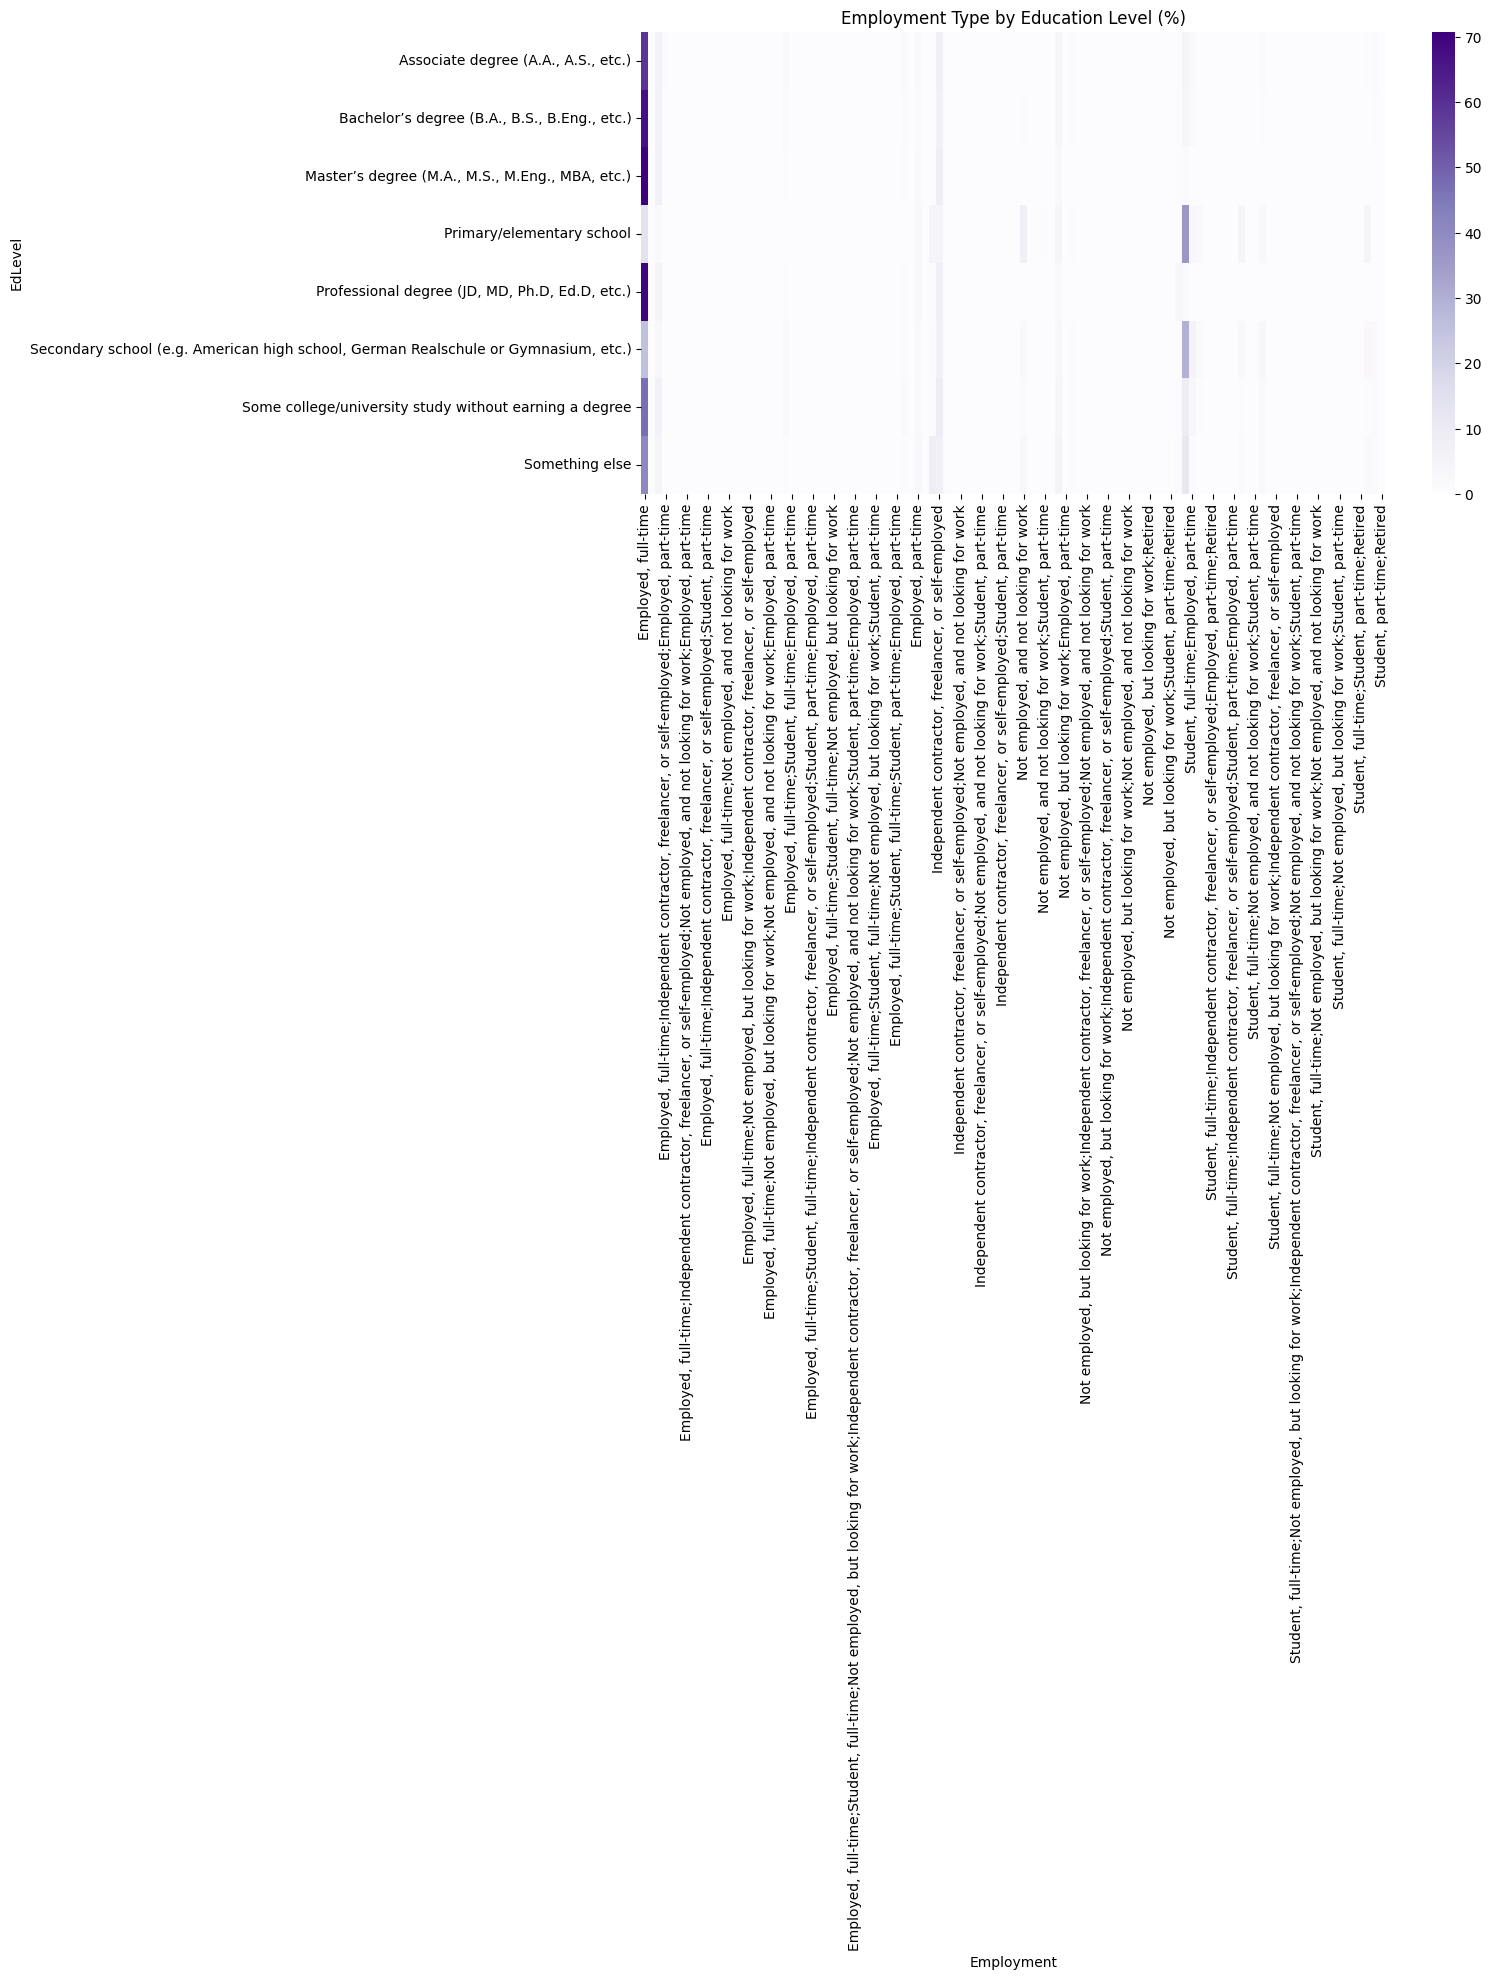

In [13]:
## Write your code here
edu_emp = pd.crosstab(df["EdLevel"], df["Employment"], normalize="index") * 100
print("Employment distribution within each EdLevel (%):")
display(edu_emp.round(2))

plt.figure(figsize=(12,6))
sns.heatmap(edu_emp, annot=False, cmap="Purples")
plt.title("Employment Type by Education Level (%)")
plt.xlabel("Employment")
plt.ylabel("EdLevel")
plt.tight_layout()
plt.show()

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [14]:
## Write your code here
output_file = "survey-data-cleaned.csv"
df.to_csv(output_file, index=False)
print("Saved cleaned dataset to:", output_file)

Saved cleaned dataset to: survey-data-cleaned.csv


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
